# ABSCHLUSSPROJEKT: Analyse klinischer Studiendaten zur Bewertung von Behandlungswirksamkeit

In [2]:
# Bibliothek importieren

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# PHASE 0: Planung & Vorbereitung

## 1. Datensatz laden

In [3]:
df = pd.read_csv("efficacy_df.csv")
df

C:\Users\nobom\AppData\Local\Temp\ipykernel_25720\2409687418.py:1: DtypeWarning: Columns (24,25,26,29,30,32,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("efficacy_df.csv")


,Unnamed: 0,NCT_ID,study_type,completion_year,trial_phase,enrollment_num,allocation,Countries,funder_name,funder_type,...,mapped_mesh_terms,tree_level_0,intervention_dict,comparator_dict,intervention_group,intervention_value,intervention_similarity,comparator_group,comparator_value,comparator_similarity
0,0,NCT00092677,Interventional,2008.0,Phase 3,1873.0,Randomized,[],['Organon and Co'],['Industry'],...,"['E', 'N', 'D']","['E', 'N', 'D']",[{'ezetimibe (+) simvastatin': 'Drug'}],[{'Comparator: Placebo': 'Drug'}],EZ/Simva 10/40 mg,Drug,0.832103,Placebo,Drug,0.851097
1,1,NCT00092677,Interventional,2008.0,Phase 3,1873.0,Randomized,[],['Organon and Co'],['Industry'],...,"['E', 'N', 'D']","['E', 'N', 'D']",[{'ezetimibe (+) simvastatin': 'Drug'}],[{'Comparator: Placebo': 'Drug'}],EZ/Simva 10/40 mg,Drug,0.832103,Placebo,Drug,0.851097
2,2,NCT00092677,Interventional,2008.0,Phase 3,1873.0,Randomized,[],['Organon and Co'],['Industry'],...,"['E', 'N', 'D']","['E', 'N', 'D']",[{'ezetimibe (+) simvastatin': 'Drug'}],[{'Comparator: Placebo': 'Drug'}],EZ/Simva 10/40 mg,Drug,0.832103,Placebo,Drug,0.851097
3,3,NCT00092677,Interventional,2008.0,Phase 3,1873.0,Randomized,[],['Organon and Co'],['Industry'],...,"['E', 'N']","['E', 'N']",[{'ezetimibe (+) simvastatin': 'Drug'}],[{'Comparator: Placebo': 'Drug'}],EZ/Simva 10/40 mg,Drug,0.832103,Placebo,Drug,0.851097
4,4,NCT00112437,Interventional,2016.0,Phase 2,399.0,Randomized,[],['Merck Sharp & Dohme LLC'],['Industry'],...,"['G', 'A']","['G', 'A']","[{'Odanacatib': 'Drug'}, {'Odanacatib': 'Drug'...",[{'Placebo': 'Drug'}],Odanacatib 50 Mg-Base,Drug,0.912584,Placebo-Base,Drug,0.858795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119963,222293,NCT04617509,Interventional,2020.0,Phase 1,14.0,Non-Randomized,['Sweden'],"['Gesynta Pharma AB', 'CTC Clinical Trial Cons...","['Industry', 'Industry', 'Other']",...,[],[],[{'Formulation A GS-248': 'Drug'}],[{'Formulation B GS-248': 'Drug'}],Part I GS-248 Formulation A,Drug,0.934215,Part I GS-248 Formulation B,Drug,0.936646
119964,222294,NCT04617509,Interventional,2020.0,Phase 1,14.0,Non-Randomized,['Sweden'],"['Gesynta Pharma AB', 'CTC Clinical Trial Cons...","['Industry', 'Industry', 'Other']",...,[],[],[{'Formulation A GS-248': 'Drug'}],[{'Formulation B GS-248': 'Drug'}],Part II GS-248 Formulation A in Fed Condition,Drug,0.904189,Part II GS-248 Formulation A in Fed Condition,Drug,0.910622
119965,222295,NCT04617509,Interventional,2020.0,Phase 1,14.0,Non-Randomized,['Sweden'],"['Gesynta Pharma AB', 'CTC Clinical Trial Cons...","['Industry', 'Industry', 'Other']",...,[],[],[{'Formulation A GS-248': 'Drug'}],[{'Formulation B GS-248': 'Drug'}],Part I GS-248 Formulation A,Drug,0.934215,Part I GS-248 Formulation B,Drug,0.936646
119966,222296,NCT04617509,Interventional,2020.0,Phase 1,14.0,Non-Randomized,['Sweden'],"['Gesynta Pharma AB', 'CTC Clinical Trial Cons...","['Industry', 'Industry', 'Other']",...,[],[],[{'Formulation A GS-248': 'Drug'}],[{'Formulation B GS-248': 'Drug'}],Part II GS-248 Formulation A in Fed Condition,Drug,0.904189,Part II GS-248 Formulation A in Fed Condition,Drug,0.910622


## 2. Größe des Datensatzes prüfen

In [223]:
print(f"\n📊 Größe:")
print(f"  Zeilen (Einträge): {len(df):,}")
print(f"  Spalten: {len(df.columns)}")
# Zeilen = 119968  -- Studien-Ergebnisse
# Spalten = 49     -- Variablen


📊 Größe:
  Zeilen (Einträge): 119,928
  Spalten: 50


## 3. Erste Zeilen anschauen

In [230]:
# ERSTE 5 ZEILEN

print(f"\n3️⃣ ERSTE 5 ZEILEN:")
print(df.head())


3️⃣ ERSTE 5 ZEILEN:
   Unnamed: 0       NCT_ID      study_type  completion_year trial_phase  \
0           0  NCT00092677  Interventional           2008.0     Phase 3   
1           1  NCT00092677  Interventional           2008.0     Phase 3   
2           2  NCT00092677  Interventional           2008.0     Phase 3   
3           3  NCT00092677  Interventional           2008.0     Phase 3   
4           4  NCT00112437  Interventional           2016.0     Phase 2   

   enrollment_num  allocation Countries                  funder_name  \
0          1873.0  Randomized        []           ['Organon and Co']   
1          1873.0  Randomized        []           ['Organon and Co']   
2          1873.0  Randomized        []           ['Organon and Co']   
3          1873.0  Randomized        []           ['Organon and Co']   
4           399.0  Randomized        []  ['Merck Sharp & Dohme LLC']   

    funder_type  ...                                  intervention_dict  \
0  ['Industry']  ...

## 4. Spaltenübersicht

In [229]:
# Spalten-Namen anzeigen

print(f"\n4️⃣ SPALTEN-NAMEN ({len(df.columns)} insgesamt):")
print(f"\n📋 Alle Spalten:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


4️⃣ SPALTEN-NAMEN (50 insgesamt):

📋 Alle Spalten:
   1. Unnamed: 0
   2. NCT_ID
   3. study_type
   4. completion_year
   5. trial_phase
   6. enrollment_num
   7. allocation
   8. Countries
   9. funder_name
  10. funder_type
  11. condition_mesh
  12. intervention_mesh
  13. condition
  14. age
  15. all_inters
  16. intervention_type
  17. intervention
  18. comparator
  19. comparator_type
  20. outcome_id
  21. info
  22. groups
  23. outcome_type
  24. outcome_title
  25. p_value
  26. method
  27. method_desc
  28. ci_percent
  29. ci_n_sides
  30. ci_lower_limit
  31. ci_upper_limit
  32. param_type
  33. param_value
  34. split_p
  35. p_split
  36. label
  37. ci_upper_limit_clean
  38. mesh_terms_mti
  39. mapped_mesh_terms
  40. tree_level_0
  41. intervention_dict
  42. comparator_dict
  43. intervention_group
  44. intervention_value
  45. intervention_similarity
  46. comparator_group
  47. comparator_value
  48. comparator_similarity
  49. p_value_numeric
  50. signif

In [8]:
# Werte einer bestimmten Spalte ansehen

df["trial_phase"].unique()

df["p_value"].unique()

array(['<=0.001', '<=0.0002', '<=0.05', ..., '=0.2595', '=0.3898', nan],
      shape=(15192,), dtype=object)

## 5. Datentypen prüfen

In [228]:
print(f"\n5️⃣ DATENTYPEN:")
print(df.dtypes)


5️⃣ DATENTYPEN:
Unnamed: 0                   int64
NCT_ID                      object
study_type                  object
completion_year            float64
trial_phase                 object
enrollment_num             float64
allocation                  object
Countries                   object
funder_name                 object
funder_type                 object
condition_mesh              object
intervention_mesh           object
condition                   object
age                         object
all_inters                  object
intervention_type           object
intervention                object
comparator                  object
comparator_type             object
outcome_id                   int64
info                        object
groups                      object
outcome_type                object
outcome_title               object
p_value                     object
method                      object
method_desc                 object
ci_percent                 float64
ci_

## 6. Statistische Übersicht

In [234]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119928 entries, 0 to 119967
Data columns (total 50 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Unnamed: 0               119928 non-null  int64  
 1   NCT_ID                   119928 non-null  object 
 2   study_type               119928 non-null  object 
 3   completion_year          117243 non-null  float64
 4   trial_phase              119928 non-null  object 
 5   enrollment_num           119928 non-null  float64
 6   allocation               119928 non-null  object 
 7   Countries                119928 non-null  object 
 8   funder_name              119928 non-null  object 
 9   funder_type              119928 non-null  object 
 10  condition_mesh           119928 non-null  object 
 11  intervention_mesh        119928 non-null  object 
 12  condition                119928 non-null  object 
 13  age                      119928 non-null  object 
 14  all_inter

## 7. Fehlende Werte prüfen

In [231]:
print(f"\n7️⃣ FEHLENDE WERTE:")
fehlende = df.isnull().sum()
spalten_mit_fehler = fehlende[fehlende > 0]

if len(spalten_mit_fehler) == 0:
    print("  ✅ Keine fehlenden Werte!")
else:
    print(f"  ⚠️ {len(spalten_mit_fehler)} Spalten haben fehlende Werte:")
    for spalte, anzahl in spalten_mit_fehler.items():
        prozent = anzahl / len(df) * 100
        print(f"    - {spalte}: {anzahl:,} ({prozent:.1f}%)")

# Fehlende Werte berechnen


7️⃣ FEHLENDE WERTE:
  ⚠️ 8 Spalten haben fehlende Werte:
    - completion_year: 2,685 (2.2%)
    - p_value: 10,076 (8.4%)
    - ci_n_sides: 39,742 (33.1%)
    - ci_lower_limit: 33,627 (28.0%)
    - ci_upper_limit: 33,880 (28.3%)
    - param_value: 30,500 (25.4%)
    - ci_upper_limit_clean: 109,852 (91.6%)
    - p_value_numeric: 10,454 (8.7%)


## 8. Verteilungen

In [24]:
# Teilnehmerzahl

df['enrollment_num'].describe()

count    119928.000000
mean        699.583275
std        2109.463199
min           5.000000
25%         126.000000
50%         315.000000
75%         626.000000
max      150395.000000
Name: enrollment_num, dtype: float64

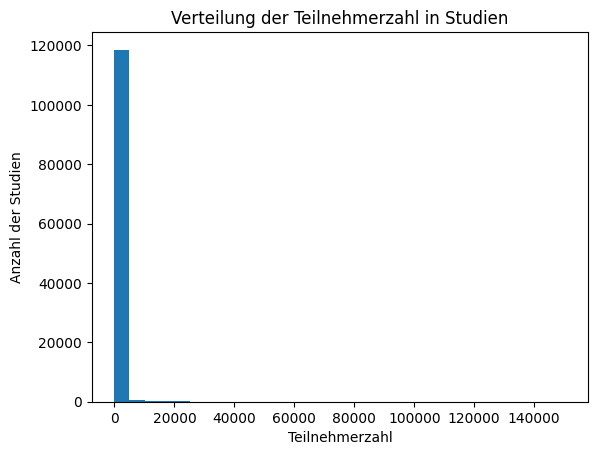

In [13]:
# Visualisierung (Histogramm)

plt.hist(df['enrollment_num'], bins=30)
plt.xlabel("Teilnehmerzahl")
plt.ylabel("Anzahl der Studien")
plt.title("Verteilung der Teilnehmerzahl in Studien")
plt.show()

In [14]:
# p-Werte

df['p_value'].describe()

count     109892
unique     15191
top       <0.001
freq       11828
Name: p_value, dtype: object

In [15]:
df['p_value'].head(100)

0     <=0.001
1     <=0.001
2     <=0.001
3     <=0.001
4     <=0.001
       ...   
95     <0.001
96     <0.001
97     <0.001
98     <0.001
99     <0.001
Name: p_value, Length: 100, dtype: object

In [16]:
# p_value_numeric erstellen

df['p_value_numeric'] = (
    df['p_value']
    .astype(str)
    .str.replace(r'[^0-9\.eE-]', '', regex=True)
)

df['p_value_numeric'] = pd.to_numeric(df['p_value_numeric'], errors='coerce')

In [17]:
df['p_value_numeric'].describe() 

df[df['p_value_numeric'] < 0]  # prüfen wir unmögliche Werte

df[df['p_value_numeric'] < 0].head()

df.loc[df['p_value_numeric'] < 0, 'p_value_numeric'] = None

# Prüfung nach der Bereinigung
df[df['p_value_numeric'] < 0]

# Wir filtern gültige p-Werte.
df.loc[(df['p_value_numeric'] < 0) | (df['p_value_numeric'] > 1), 'p_value_numeric'] = None

In [18]:
# Prüfung nach der Bereinigung
df['p_value_numeric'].describe()

df[df['p_value_numeric'] > 1]   # Prüfung auf unmögliche Werte über 1

,Unnamed: 0,NCT_ID,study_type,completion_year,trial_phase,enrollment_num,allocation,Countries,funder_name,funder_type,...,tree_level_0,intervention_dict,comparator_dict,intervention_group,intervention_value,intervention_similarity,comparator_group,comparator_value,comparator_similarity,p_value_numeric


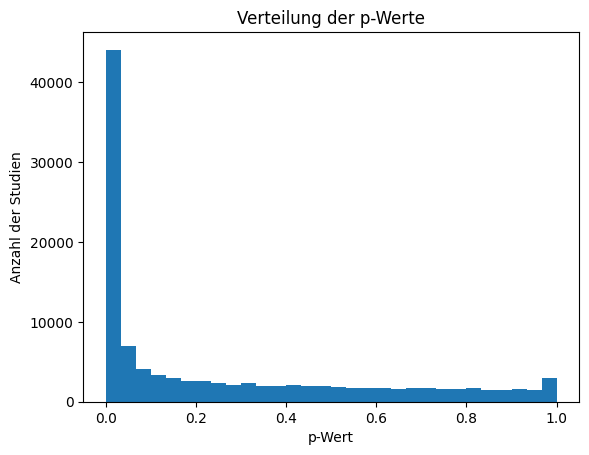

In [19]:
# Histogramm der p-Werte

plt.hist(df['p_value_numeric'], bins=30)
plt.xlabel("p-Wert")
plt.ylabel("Anzahl der Studien")
plt.title("Verteilung der p-Werte")
plt.show()

In [20]:
# Anteil signifikanter Ergebnisse

(df['p_value_numeric'] <= 0.05).mean()


# 41 % der Studien zeigen ein signifikantes Ergebnis

np.float64(0.40632502000533477)

In [21]:
# Fehlende Werte prüfen (für diese Variablen)

df[['enrollment_num','p_value_numeric']].isnull().sum() 


enrollment_num        40
p_value_numeric    10454
dtype: int64

In [22]:
# Wenn das Ergebnis ≤ 1 ist, dann sind p-Werte jetzt sauber

df['p_value_numeric'].max()

np.float64(1.0)

## ZUSAMMENFASSUNG

In [233]:
print(f"\n" + "=" * 70)
print("ZUSAMMENFASSUNG")
print("=" * 70)

print(f"\n✅ Datensatz Größe: {len(df):,} Zeilen × {len(df.columns)} Spalten")
print(f"✅ Fehlende Werte: {df.isnull().sum().sum():,} insgesamt")
print(f"✅ Alle wichtigen Spalten vorhanden? Ja! ✓")
print(f"\n👍 Der Datensatz ist bereit für Phase 1!")

print(f"\n" + "=" * 70)


ZUSAMMENFASSUNG

✅ Datensatz Größe: 119,928 Zeilen × 50 Spalten
✅ Fehlende Werte: 270,816 insgesamt
✅ Alle wichtigen Spalten vorhanden? Ja! ✓

👍 Der Datensatz ist bereit für Phase 1!



# PHASE 1: DATENBEREINIGUNG 

### SCHRITT 1: FEHLENDE WERTE ANALYSIEREN

In [249]:
print("\n1. FEHLENDE WERTE ANALYSIEREN...")

# Zähle fehlende Werte
fehlende = df.isnull().sum()
fehlende_prozent = (fehlende / len(df)) * 100


# Sortiere nach Anzahl (absteigend)
fehlende_sorted = fehlende.sort_values(ascending=False)

print(f"\n📊 GESAMTÜBERSICHT:")
print(f"  Gesamt fehlende Werte: {fehlende.sum():,}")
print(f"  Spalten mit Fehlern: {(fehlende > 0).sum()}")
print(f"  Spalten ohne Fehler: {(fehlende == 0).sum()}")


1. FEHLENDE WERTE ANALYSIEREN...

📊 GESAMTÜBERSICHT:
  Gesamt fehlende Werte: 270,816
  Spalten mit Fehlern: 8
  Spalten ohne Fehler: 42


## SCHRITT 2: DETAILLIERTE LISTE

In [248]:
print(f"\n2. DETAILLIERTE LISTE DER FEHLENDEN WERTE:")
print(f"\n{'Spalte':<30} {'Fehlend':<10} {'%':<8} {'Status':<20}")
print("-" * 80)


# Definiere kritische Schwellen
for spalte in fehlende_sorted.index:
    anzahl = fehlende[spalte]
    prozent = fehlende_prozent[spalte]
    
    if anzahl == 0:
        status = "✅ OK"
    elif prozent < 5:
        status = "⚠️ Wenige Fehler"
    elif prozent < 20:
        status = "⚠️ Einige Fehler"
    else:
        status = "🔴 Viele Fehler!"
    
    print(f"{spalte:<30} {anzahl:<10,} {prozent:<8.1f} {status:<20}")


# Fazit: Die meisten Spalten sind sauber, aber einige haben signifikante Lücken. Wir sollten diese kritisch prüfen, bevor wir mit der Analyse fortfahren.



2. DETAILLIERTE LISTE DER FEHLENDEN WERTE:

Spalte                         Fehlend    %        Status              
--------------------------------------------------------------------------------
ci_upper_limit_clean           109,852    91.6     🔴 Viele Fehler!     
ci_n_sides                     39,742     33.1     🔴 Viele Fehler!     
ci_upper_limit                 33,880     28.3     🔴 Viele Fehler!     
ci_lower_limit                 33,627     28.0     🔴 Viele Fehler!     
param_value                    30,500     25.4     🔴 Viele Fehler!     
p_value_numeric                10,454     8.7      ⚠️ Einige Fehler    
p_value                        10,076     8.4      ⚠️ Einige Fehler    
completion_year                2,685      2.2      ⚠️ Wenige Fehler    
NCT_ID                         0          0.0      ✅ OK                
funder_type                    0          0.0      ✅ OK                
condition_mesh                 0          0.0      ✅ OK                
study_type

## SCHRITT 3: WICHTIGE SPALTEN ÜBERPRÜFEN

In [250]:
print(f"\n3. ÜBERPRÜFUNG DER 5 WICHTIGEN SPALTEN:")

wichtige_spalten = {
    'significant': 'Erfolgsrate',
    'completion_year': 'Zeittrend',
    'intervention_type': 'Medikament vs Gerät',
    'condition': 'Top Krankheiten',
    'funder_type': 'Industrie vs Öffentlich'
}

print(f"\n{'Spalte':<25} {'Für Frage':<25} {'Fehlend':<10} {'Status':<15}")
print("-" * 80)

for spalte, frage in wichtige_spalten.items():
    if spalte in df.columns:
        fehler = df[spalte].isnull().sum()
        fehler_pct = (fehler / len(df)) * 100
        
        if fehler == 0:
            status = "✅ PERFEKT"
        elif fehler_pct < 5:
            status = "✅ OK"
        else:
            status = f"⚠️ {fehler_pct:.1f}% Fehler"
        
        print(f"{spalte:<25} {frage:<25} {fehler:<10,} {status:<15}")
    else:
        print(f"{spalte:<25} {frage:<25} {'N/A':<10} ❌ NICHT VORHANDEN")



3. ÜBERPRÜFUNG DER 5 WICHTIGEN SPALTEN:

Spalte                    Für Frage                 Fehlend    Status         
--------------------------------------------------------------------------------
significant               Erfolgsrate               0          ✅ PERFEKT      
completion_year           Zeittrend                 2,685      ✅ OK           
intervention_type         Medikament vs Gerät       0          ✅ PERFEKT      
condition                 Top Krankheiten           0          ✅ PERFEKT      
funder_type               Industrie vs Öffentlich   0          ✅ PERFEKT      


In [25]:
# Spalte 1 — Unnamed: 0

df['Unnamed: 0'].head()

df['Unnamed: 0'].describe()

# df = df.drop(columns=['Unnamed: 0'])

# Die Spalte „Unnamed: 0“ stellte einen automatisch generierten Index aus dem CSV-Export dar 
# und enthielt keine analytisch relevante Information. Sie wurde daher aus dem Datensatz entfernt.
# Spalte entfernen

count    119968.000000
mean     108232.783209
std       63210.254196
min           0.000000
25%       53328.750000
50%      108510.500000
75%      163041.250000
max      222314.000000
Name: Unnamed: 0, dtype: float64

In [37]:
# Spalte 2 — NCT_ID

df['NCT_ID'].dtype         # NCT_ID ist ein Objekt (String)

df['NCT_ID'].isnull().sum()  # NCT_ID ist vollständig, keine fehlenden Werte

df['NCT_ID'].duplicated().sum() # 111303 Zeilen haben eine NCT_ID, die bereits vorher im Datensatz vorkommt : Viele Studien erscheinen mehr als einmal.

df['NCT_ID'].nunique()  # Es gibt 8665 Studien in dem Datensatz



# NCT_ID ist eine eindeutige Identifikationsnummer für klinische Studien.
# Die Variable NCT_ID identifiziert jede klinische Studie eindeutig. 
# Sie wurde im Datensatz beibehalten, um Studien zu identifizieren und mögliche Mehrfacheinträge zu analysieren.
# Spalte behalten

8665

In [41]:
# Spalte 3 — study_type

df['study_type'].unique()   # Das zeigt alle Kategorien von Studientypen

df['study_type'].value_counts()

df['study_type'].isnull().sum()

df['study_type'].dtype


# Die Variable study_type beschreibt den Typ der klinischen Studie und wurde als kategoriale Variable im Datensatz beibehalten.
# Spalte behalten

dtype('O')

In [55]:
# Spalte 4 — completion_year

df['completion_year'].dtype

df['completion_year'].describe()

df['completion_year'].isnull().sum()   # Es gibt 2535 fehlende Werte in der Spalte completion_year

df[df['completion_year'] < 1950]

df[df['completion_year'] > 2025]

df['completion_year'].value_counts().sort_index()  # Häufigkeit der Studienabschlüsse pro Jahr

df['completion_year'].max()

df.loc[df['completion_year'] > 2025, 'completion_year'] = None  # Ungültige Werte über 2025 auf None setzen

df['completion_year'].max()

df['completion_year'].isna().mean() * 100  # Anteil fehlender Werte in completion_year (2,2 %)

df_year = df.dropna(subset=['completion_year'])


# Die Variable completion_year beschreibt das Jahr, in dem eine klinische Studie abgeschlossen wurde. 
# Sie wurde als numerische Variable im Datensatz beibehalten, um zeitliche Trends analysieren zu können.
# Spalte behalten

In [67]:
# Spalte 5 — trial_phase

df['trial_phase'].unique()

df['trial_phase'].value_counts()

df['trial_phase'].isnull().sum()   # Es gibt 8127 fehlende Werte in der Spalte trial_phase

df['trial_phase'].dtype

df.groupby('study_type')['trial_phase'].apply(lambda x: x.isna().sum())

df['trial_phase'].isna().mean() * 100  # Anteil fehlender Werte in trial_phase (6,8 %)

df['trial_phase'] = df['trial_phase'].fillna('Unknown Phase')

df['trial_phase'].isna().sum()

df['trial_phase'].value_counts()



# zeigt, in welcher Phase eine klinische Studie durchgeführt wurde.
# Die Variable trial_phase beschreibt die Entwicklungsphase der klinischen Studie und wurde als kategoriale Variable im Datensatz beibehalten.
# Fehlende Werte in der Variable trial_phase wurden als „Unknown Phase“ kodiert, da für einige Interventional Studies keine Phaseninformation verfügbar war.
# Spalte behalten

trial_phase
Phase 3            56371
Phase 2            37525
Phase 4             9913
Unknown Phase       8127
Phase 1             4698
Phase 1/Phase 2     1723
Phase 2/Phase 3     1514
Early Phase 1         97
Name: count, dtype: int64

In [75]:
# Spalte 6 — enrollment_num

df['enrollment_num'].dtype

df['enrollment_num'].describe()

df[df['enrollment_num'] <= 0]  # Unmögliche Werte prüfen

df['enrollment_num'].max()

df['enrollment_num'].isna().sum()

df = df.dropna(subset=['enrollment_num'])



# wie viele Teilnehmer an einer klinischen Studie teilgenommen haben
# Spalte behalten

np.int64(0)

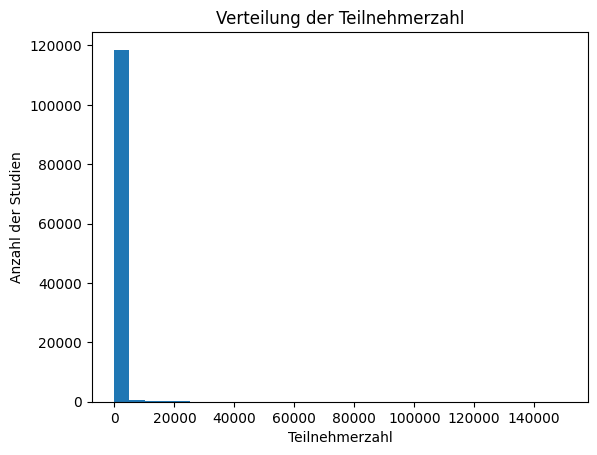

In [73]:
# Verteilung visualisieren


plt.hist(df['enrollment_num'], bins=30)
plt.xlabel("Teilnehmerzahl")
plt.ylabel("Anzahl der Studien")
plt.title("Verteilung der Teilnehmerzahl")
plt.show()

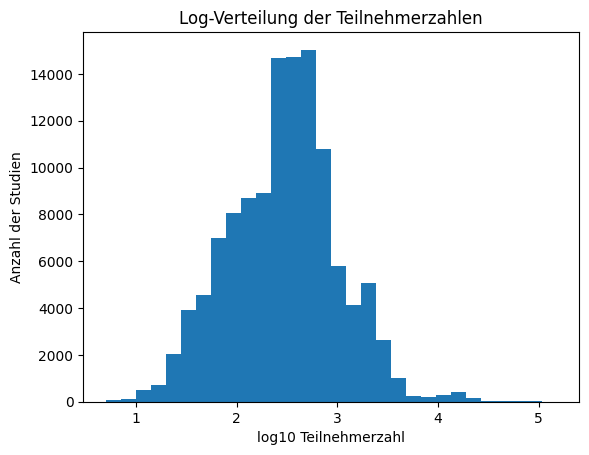

In [76]:
# Logarithmische Darstellung (sehr hilfreich)


plt.hist(np.log10(df['enrollment_num']), bins=30)
plt.xlabel("log10 Teilnehmerzahl")
plt.ylabel("Anzahl der Studien")
plt.title("Log-Verteilung der Teilnehmerzahlen")
plt.show()

In [83]:
# Spalte 7 — allocation

df['allocation'].unique()

df['allocation'].value_counts()

df['allocation'].isna().sum()

df['allocation'].dtype

df.loc[:, 'allocation'] = df['allocation'].fillna('Unknown Allocation')

df['allocation'].isna().sum()



# Die Variable allocation beschreibt die Methode der Gruppenzuteilung in klinischen Studien. 
# Fehlende Werte wurden als „Unknown Allocation“ kodiert.
# Spalte behalten

np.int64(0)

In [86]:
# Spalte 8 — Countries

df['Countries'].isna().sum()

df['Countries'].value_counts().head(10)



# Die Variable Countries beschreibt die Länder, in denen eine klinische Studie durchgeführt wurde.
# Fehlende Werte wurden als „Unknown Country“ kodiert.

Countries
['United States']                   36077
[]                                  10452
['Japan']                            3755
['Canada']                           3633
['Australia']                        3151
['Argentina']                        2855
['Canada', 'United States']          2641
['Puerto Rico', 'United States']     1370
['China']                            1353
['Germany']                          1204
Name: count, dtype: int64

In [89]:
# Spalte 9 — funder_name

df['funder_name'].isna().sum()

df['funder_name'].nunique()

df['funder_name'].value_counts().head(10)



# Die Variable funder_name beschreibt die Organisation, die eine klinische Studie finanziert hat. 
# Spalte behalten.

funder_name
['Pfizer']                                                        16820
['Eli Lilly and Company']                                          6270
['GlaxoSmithKline']                                                5905
["Pfizer's Upjohn has merged with Mylan to form Viatris Inc."]     4100
['Boehringer Ingelheim']                                           3915
['Merck Sharp & Dohme LLC']                                        3522
['Takeda']                                                         3068
['Amgen']                                                          2338
['Novartis Pharmaceuticals']                                       2257
['Hoffmann-La Roche']                                              1772
Name: count, dtype: int64

In [94]:
# Spalte 10 — funder_type

df['funder_type'].unique()

df['funder_type'].value_counts()

df['funder_type'].isna().sum()



# Die Variable funder_type beschreibt die Art der Organisation, die eine klinische Studie finanziert hat. 
# Spalte behalten, da sie wichtige Informationen über die Finanzierung von Studien liefert. Fehlende Werte wurden als „Unknown Funder Type“ kodiert.

np.int64(0)

In [98]:
# Spalte 11 — condition_mesh (Medical Subject Headings)

df['condition_mesh'].isna().sum()

df['condition_mesh'].nunique()

df['condition_mesh'].value_counts().head(10)


# Die Variable condition_mesh enthält standardisierte MeSH-Begriffe zur Beschreibung der untersuchten
# Spaltt behalten

condition_mesh
[]                                                                                           9779
['Diabetes Mellitus', 'Diabetes Mellitus, Type 2']                                           5305
['Arthritis', 'Arthritis, Rheumatoid']                                                       4282
['Asthma']                                                                                   3364
['Psoriasis']                                                                                2538
['Lung Diseases', 'Lung Diseases, Obstructive', 'Pulmonary Disease, Chronic Obstructive']    2471
['Toothache']                                                                                2303
['Diabetes Mellitus']                                                                        1775
['Alzheimer Disease']                                                                        1721
['Osteoarthritis', 'Osteoarthritis, Knee']                                                   1605
Name:

In [104]:
# Spalte 12 — intervention_mesh

df['intervention_mesh'].isna().sum()

df['intervention_mesh'].nunique()

df['intervention_mesh'].value_counts().head(10)



# Die Variable intervention_mesh beschreibt die getesteten medizinischen Interventionen auf Basis standardisierter MeSH-Begriffe.
# Spalte behalten

intervention_mesh
[]                                                            30744
['Pregabalin']                                                 3249
['Tanezumab']                                                  1851
['Duloxetine Hydrochloride']                                   1372
['Acetaminophen']                                              1207
['Acetaminophen', 'Ibuprofen']                                 1160
['Tiotropium Bromide', 'Olodaterol']                           1010
['Vaccines', 'Heptavalent Pneumococcal Conjugate Vaccine']     1007
['Heptavalent Pneumococcal Conjugate Vaccine']                  931
['Vaccines']                                                    930
Name: count, dtype: int64

In [101]:
# Spalte 13 — condition

df['condition'].nunique()

df['condition'].value_counts().head(10)

df.loc[:, 'condition'] = df['condition'].fillna('Unknown Condition')



# Die Variable condition beschreibt die untersuchte Krankheit im Originaltext der Studie und wurde im Datensatz beibehalten.

In [107]:
# Spalte 14 — age

df['age'].unique()

df['age'].value_counts()

df['age'].isna().sum()


# Die Variable age beschreibt die Altersgruppen der Studienteilnehmer.
# Spalte behalten

np.int64(0)

In [111]:
# Spalte 15 — all_inters

df['all_inters'].isna().sum()

df['all_inters'].nunique()

df['all_inters'].value_counts().head(10)


# Die Variable all_inters enthält die im Originaltext der Studie beschriebenen Interventionen und wurde im Datensatz beibehalten.

all_inters
['Estradiol', 'Progesterone', 'Placebo']                                                                                                                               883
['Ibuprofen/acetaminophen', 'Ibuprofen/acetaminophen', 'Ibuprofen/acetaminophen', 'Ibuprofen', 'Placebo']                                                              854
['Ibuprofen 250 mg / Acetaminophen 500 mg', 'Ibuprofen 250 mg', 'Acetaminophen 650 mg', 'Placebo']                                                                     767
['Placebo to Week 16; tanezumab 5mg SC', 'Placebo to Week 16, tanezumab 10 mg SC', 'Tanezumab 5 mg SC', 'Tanezumab 10 mg SC', 'Tramadol PR oral']                      737
['Duloxetine', 'Placebo']                                                                                                                                              727
['PF-04965842 100 mg', 'PF-04965842 200 mg', 'Placebo']                                                                               

In [114]:
# Spalte 16 — intervention_type

df['intervention_type'].unique()

df['intervention_type'].value_counts()

df['intervention_type'].isna().sum()


# Die Variable intervention_type beschreibt die Art der getesteten medizinischen Intervention und wurde im Datensatz beibehalten.

np.int64(0)

In [117]:
# Spalte 17 — intervention

df['intervention'].isna().sum()

df['intervention'].nunique()

df['intervention'].value_counts().head(10)


# Die Variable intervention beschreibt die konkret getestete Behandlung oder Intervention in der Studie und wurde im Datensatz beibehalten.

intervention
['Estradiol', 'Progesterone']                                                        883
['Duloxetine']                                                                       861
['Ibuprofen/acetaminophen', 'Ibuprofen/acetaminophen', 'Ibuprofen/acetaminophen']    854
['Ibuprofen 250 mg / Acetaminophen 500 mg']                                          806
['Tanezumab 5 mg SC', 'Tanezumab 10 mg SC']                                          737
['tiotropium + olodaterol', 'tiotropium + olodaterol']                               670
['pregabalin']                                                                       624
['Pregabalin', 'Pregabalin', 'Pregabalin']                                           605
['PF-04965842 100 mg', 'PF-04965842 200 mg']                                         585
['PF-06700841']                                                                      564
Name: count, dtype: int64

In [120]:
# Spalte 18 — comparator

df['comparator'].head()

df['comparator'].isna().sum()

df['comparator'].value_counts().head(10)


# Die Variable comparator beschreibt die Vergleichsbehandlung einer klinischen Studie und wurde im Datensatz beibehalten.


comparator
['Placebo']                                                                                               38372
['placebo']                                                                                                7003
['Ibuprofen', 'Placebo']                                                                                    999
['NSAID']                                                                                                   943
['Ibuprofen 250 mg', 'Acetaminophen 650 mg', 'Placebo']                                                     767
['Placebo to Week 16; tanezumab 5mg SC', 'Placebo to Week 16, tanezumab 10 mg SC', 'Tramadol PR oral']      737
['Vehicle (Placebo)']                                                                                       549
['Methotrexate']                                                                                            540
['Placebo', 'crushed oxycodone IR 60 mg', 'crushed oxycodone IR 40 mg']                      

In [123]:
# Spalte 19 — comparator_type

df['comparator_type'].unique()

df['comparator_type'].value_counts()

df['comparator_type'].isna().sum()

# Die Variable comparator_type beschreibt die Art der Vergleichsbehandlung einer klinischen Studie und wurde im Datensatz beibehalten.

np.int64(0)

In [126]:
# Spalte 20 — outcome_id

df['outcome_id'].dtype

df['outcome_id'].isna().sum()

df[df['outcome_id'] <= 0]    # Unmögliche Werte prüfen


# Die Variable outcome_id identifiziert einzelne gemessene Ergebnisse innerhalb einer klinischen Studie
# Spalte behalten

,Unnamed: 0,NCT_ID,study_type,completion_year,trial_phase,enrollment_num,allocation,Countries,funder_name,funder_type,...,tree_level_0,intervention_dict,comparator_dict,intervention_group,intervention_value,intervention_similarity,comparator_group,comparator_value,comparator_similarity,p_value_numeric


In [127]:
# Spalte 21 — info

df['info'].isna().sum()

# Die Variable info enthält zusätzliche textuelle Informationen zu den gemessenen Outcomes und wurde im Datensatz beibehalten.

np.int64(0)

In [129]:
# Spalte 22 — groups

df['groups'].isna().sum()

df['groups'].value_counts().head(10)


# Die Variable groups beschreibt die Teilnehmergruppen innerhalb einer klinischen Studie und wurde im Datensatz beibehalten.

groups
['Pregabalin', 'Placebo']             714
['Duloxetine', 'Placebo']             642
['Placebo', 'SAGE-547 90 μg/kg/h']    506
['SU011248', 'IFN-α']                 373
['Placebo', 'GSK2269557 1000 mcg']    368
['Pregabalin 300 mg', 'Placebo']      351
['Placebo', 'Olo 10 mcg qd']          340
['Placebo', 'Olo 5 mcg qd']           338
['13vPnC', '7vPnC']                   328
['Placebo', 'GSK3196165 180 mg']      325
Name: count, dtype: int64

In [132]:
# Spalte 23 — outcome_type

df['outcome_type'].unique()

df['outcome_type'].value_counts()

df['outcome_type'].isna().sum()


# Die Variable outcome_type beschreibt, ob ein Studienergebnis als primäres oder sekundäres Outcome klassifiziert wurde.

np.int64(0)

In [136]:
# Spalte 24 — outcome_title

df['outcome_title'].isna().sum()

df['outcome_title'].nunique()

df['outcome_title'].value_counts().head(10)



# Die Variable outcome_title beschreibt den Titel des gemessenen Studienergebnisses und wurde im Datensatz beibehalten

outcome_title
Change From Baseline in HAM-D Individual Item Scores                                                         729
Overall Survival (OS)                                                                                        293
Cumulative Percentage of Participants With Meaningful Relief                                                 264
Cumulative Percentage of Participants With Confirmed First Perceptible Relief                                256
Overall Survival                                                                                             211
Pain Intensity Difference on 4-Point Categorical Scale (PID4)                                                195
Sum of Pain Relief Rating and Pain Intensity Difference on 4-Point Categorical Scale (PRID4)                 195
Pain Intensity Difference on 11-Point Numerical Scale (PID11)                                                195
Cumulative Percentage of Participants With Treatment Failure                      

In [141]:
# Spalte 25 — p_value_numeric

df['p_value_numeric'].describe()

df['p_value_numeric'].isna().sum()

df.loc[:, 'significant'] = df['p_value_numeric'] < 0.05    # Neue Spalte „significant“ erstellen, die angibt, ob das Ergebnis statistisch signifikant ist (p < 0.05)

df['significant'].value_counts()

significant
False    72544
True     47384
Name: count, dtype: int64

In [145]:
# Spalte 26 — method

df['method'].head()

df['method'].isna().sum()

df['method'].value_counts().head(10)

df.loc[:, 'method'] = df['method'].fillna('Unknown Method')


# Die Variable method beschreibt den statistischen Test, der zur Berechnung des p-Wertes verwendet wurde.

In [147]:
# Spalte 27 — method_desc

df['method_desc'].isna().sum()

df.loc[:, 'method_desc'] = df['method_desc'].fillna('No Method Description')

In [154]:
# Spalte 28 — ci_percent

df['ci_percent'].value_counts().sort_values(ascending=False)

df['ci_percent'].isna().sum()

df['ci_percent'].describe()

df.loc[:, 'ci_percent'] = df['ci_percent'].fillna(0)



# Die Variable ci_percent beschreibt das Konfidenzniveau des berichteten Konfidenzintervalls.
# Spalte behalten

np.int64(0)

In [156]:
# Spalte 29 — ci_n_sides

df['ci_n_sides'].value_counts()

df['ci_n_sides'].isna().sum()

# Die Variable ci_n_sides beschreibt, ob ein Konfidenzintervall einseitig oder zweiseitig angegeben wurde.

np.int64(39742)

In [ ]:
# Spalte 30 — ci_lower_limit

import pandas as pd

# Convert columns to numeric to handle mixed types
df.loc[:, 'ci_lower_limit'] = pd.to_numeric(df['ci_lower_limit'], errors='coerce')
df.loc[:, 'ci_upper_limit'] = pd.to_numeric(df['ci_upper_limit'], errors='coerce')

df['ci_lower_limit'].describe()

(df['ci_lower_limit'] > df['ci_upper_limit']).sum()  # Überprüfen, ob der untere Grenzwert größer als der obere Grenzwert ist (unmögliche Werte)


# Die Variable ci_lower_limit beschreibt die untere Grenze des berichteten Konfidenzintervalls.

np.int64(0)

In [ ]:
# Spalte 31 — ci_upper_limit

df['ci_upper_limit'].describe()

df['ci_upper_limit'].isna().sum()

(df['ci_upper_limit'] < df['ci_lower_limit']).sum()


# Die Variable ci_upper_limit beschreibt die obere Grenze des berichteten Konfidenzintervalls.

np.int64(0)

In [ ]:
# Spalte 32 — param_type

df['param_type'].unique()

df['param_type'].isna().sum()

df.loc[:, 'param_type'] = df['param_type'].fillna('Unknown Parameter')


# Die Variable param_type beschreibt die Art der statistischen Kennzahl, die für ein Studienergebnis berichtet wurde.

In [ ]:
# Spalte 33 — param_value

import pandas as pd

# Convert column to numeric to handle mixed types
df.loc[:, 'param_value'] = pd.to_numeric(df['param_value'], errors='coerce')

df['param_value'].describe()

df['param_value'].isna().sum()

df['param_value'].sort_values().head()
df['param_value'].sort_values(ascending=False).head()


# Die Variable param_value enthält den numerischen Wert der berichteten statistischen Kennzahl.

82817    69990000.0
66231     1156318.0
66230      589373.0
66229      575882.0
66227      362384.0
Name: param_value, dtype: object

In [ ]:
# Spalte 34 — split_p

df['split_p'].value_counts()

df['split_p'].isna().sum()

df.loc[:, 'split_p'] = df['split_p'].fillna(False)


# Die Variable split_p zeigt, ob ein p-Wert aus einer textuellen Darstellung extrahiert und in numerische Form überführt wurde.

In [ ]:
# Spalte 35 — p_split

df['p_split'].value_counts()

df['p_split'].isna().sum()

df.loc[:, 'p_split'] = df['p_split'].astype('object').fillna('=')


# Die Variable p_split enthält den mathematischen Operator der berichteten p-Werte (z. B. <, =).

In [ ]:
# Spalte 36 — label

df['label'].value_counts().head(10)

df['label'].isna().sum()




# Die Variable label enthält eine kurze kategoriale Bezeichnung für das jeweilige Studienergebnis.

array(['positive', 'negative'], dtype=object)

In [193]:
# Spalte 37 — ci_lower_limit_clean

df['ci_lower_limit_clean'].dtype

df['ci_lower_limit_clean'].describe()

df['ci_lower_limit_clean'].isna().sum()

df[['ci_lower_limit','ci_lower_limit_clean']].head(100)

df['ci_lower_limit_clean'].isna().mean()    # Anteil fehlender Werte in ci_lower_limit_clean (92 %)

df = df.drop(columns=['ci_lower_limit_clean'])



# Die Variable ci_lower_limit_clean wurde entfernt, da sie überwiegend fehlende Werte enthielt und keinen zusätzlichen Informationswert bot

In [194]:
# Spalte 38 — ci_upper_limit_clean

df['ci_upper_limit_clean'].isna().mean()    # Anteil fehlender Werte in ci_upper_limit_clean (92 %)

df['ci_upper_limit_clean'].isna().mean()


# Die Variable ci_upper_limit_clean wurde entfernt, da sie überwiegend fehlende Werte enthielt und keinen zusätzlichen Informationswert bot

np.float64(0.9159829230871857)

In [ ]:
# Spalte 39 — mesh_terms_mti

df['mesh_terms_mti'].head()

df['mesh_terms_mti'].isna().sum()

df.loc[:, 'mesh_terms_mti'] = df['mesh_terms_mti'].fillna('No MeSH Terms')


# Die Variable mesh_terms_mti enthält automatisch generierte MeSH-Begriffe zur thematischen Klassifikation der Studien.
# Spalte behalten

In [ ]:
# Spalte 40 — mapped_mesh_terms

df['mapped_mesh_terms'].head()

df['mapped_mesh_terms'].isna().sum()


# Die Variable mapped_mesh_terms enthält standardisierte MeSH-Begriffe zur thematischen Klassifikation der Studien.
# Spalte behalten

np.int64(0)

In [ ]:

# Spalte 41 — tree_level_0

df['tree_level_0'].value_counts()

df['tree_level_0'].isna().sum()


# Die Variable tree_level_0 beschreibt die oberste Kategorie der MeSH-Klassifikation der Studien.
# spalte behalten

np.int64(0)

In [ ]:
# Spalte 42 — intervention_dict

df['intervention_dict'].isna().sum()

# Die Variable intervention_dict enthält eine strukturierte Darstellung der Interventionen im Format eines Dictionaries.
# Spalte behalten

np.int64(0)

In [ ]:
# Spalte 43 — comparator_dict

df['comparator_dict'].isna().sum()

# Die Variable comparator_dict enthält eine strukturierte Darstellung der Vergleichsbehandlungen im Format eines Dictionaries.
# Spalte behalten

np.int64(0)

In [ ]:
# Spalte 44 — intervention_group

df['intervention_group'].head()

df['intervention_group'].isna().sum()


# Die Variable intervention_group beschreibt die Teilnehmergruppe, die die getestete Intervention erhalten hat.

np.int64(0)

In [207]:
# Spalte 45 — intervention_value

df['intervention_value'].head()

df['intervention_value'].isna().sum()

np.int64(0)

In [ ]:
# Spalte 46 — intervention_similarity

df['intervention_similarity'].describe()

df['intervention_similarity'].isna().sum()


# Die Variable intervention_similarity enthält einen numerischen Wert, der die Ähnlichkeit zwischen den getesteten Interventionen in verschiedenen Studien beschreibt.
# Spalte behalten



np.int64(0)

In [ ]:
# Spalte 47 — comparator_group

df['comparator_group'].head()

df['comparator_group'].isna().sum()


# Die Variable comparator_group beschreibt die Teilnehmergruppe, die die Vergleichsbehandlung erhalten hat.
# spalte behalten

np.int64(0)

In [ ]:
# Spalte 47 — comparator_group

df['comparator_group'].head()

df['comparator_group'].isna().sum()

# Die Variable comparator_group beschreibt die Teilnehmergruppe, die die Vergleichsbehandlung erhalten hat.
# Spalte behalten

np.int64(0)

In [220]:
# Spalte 49 — comparator_similarity

df['comparator_similarity'].describe()

df['comparator_similarity'].isna().sum()



# Die Variable comparator_similarity enthält einen numerischen Wert, der die Ähnlichkeit zwischen den Vergleichsbehandlungen in verschiedenen Studien beschreibt.
# Spalte behalten

np.int64(0)

In [ ]:
# Spalte 50 — p_value_numeric

df['p_value_numeric'].describe()

df['p_value_numeric'].isna().sum()

(df['p_value_numeric'] < 0).sum()
(df['p_value_numeric'] > 1).sum()        # Überprüfen, ob es ungültige p-Werte gibt (unter 0 oder über 1)


# Die Variable p_value_numeric enthält den numerischen p-Wert der Studienergebnisse und dient als zentrale Variable zur Bewertung der statistischen Signifikanz.
# Spalte behalten



np.int64(0)

# III. Schritt 3 — Feature Selection für die Analyse